# Fertilizer Recommendation System

This notebook develops a Machine Learning model for fertilizer recommendation.

Goal:

Predict the most suitable fertilizer based on:

- Temperature
- Humidity
- Moisture
- Soil Type
- Crop Type
- Nitrogen
- Potassium
- Phosphorous

Output:

- Recommended Fertilizer

Model:

Decision Tree Classifier

---

# Import Required Libraries

The following libraries are used for:

- Data loading
- Data preprocessing
- Visualization
- Model training
- Model evaluation
- Model saving

In [8]:
# Data manipulation
import pandas as pd

# Numerical operations
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding categorical values
from sklearn.preprocessing import LabelEncoder

# Splitting dataset
from sklearn.model_selection import train_test_split

# Machine Learning Model
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Save model
import pickle

---

# Load Fertilizer Dataset

Read the fertilizer dataset into a pandas DataFrame.

In [10]:
df = pd.read_csv("Fertilizer Prediction.csv")

df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


---

# Dataset Inspection

Check:

- Shape
- Columns
- Data Types
- Missing Values

In [11]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

Shape:
(99, 9)

Columns:
Index(['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Temparature      99 non-null     int64
 1   Humidity         99 non-null     int64
 2   Moisture         99 non-null     int64
 3   Soil Type        99 non-null     str  
 4   Crop Type        99 non-null     str  
 5   Nitrogen         99 non-null     int64
 6   Potassium        99 non-null     int64
 7   Phosphorous      99 non-null     int64
 8   Fertilizer Name  99 non-null     str  
dtypes: int64(6), str(3)
memory usage: 7.1 KB
None


---

# Missing Value Analysis

In [12]:
df.isnull().sum()

Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

---

# Statistical Summary

In [13]:
df.describe()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,30.282828,59.151515,43.181818,18.909091,3.383838,18.606061
std,3.502304,5.840331,11.271568,11.599693,5.814667,13.476978
min,25.000000,50.000000,25.000000,4.000000,0.000000,0.000000
25%,28.000000,54.000000,34.000000,10.000000,0.000000,9.000000
50%,30.000000,60.000000,41.000000,13.000000,0.000000,19.000000
75%,33.000000,64.000000,50.500000,24.000000,7.500000,30.000000
max,38.000000,72.000000,65.000000,42.000000,19.000000,42.000000


---

# Fertilizer Classes

Display all fertilizer categories.

In [14]:
print(df["Fertilizer Name"].unique())

<StringArray>
['Urea', 'DAP', '14-35-14', '28-28', '17-17-17', '20-20', '10-26-26']
Length: 7, dtype: str


---

# Fertilizer Distribution

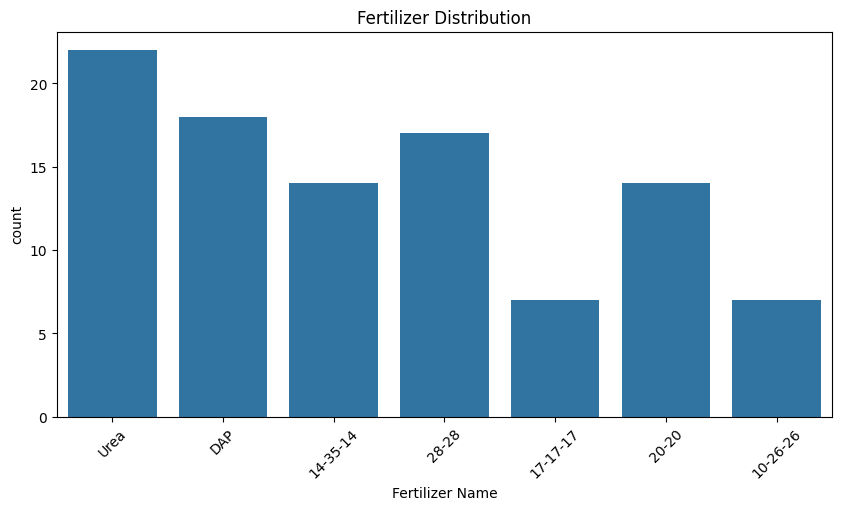

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Fertilizer Name",
    data=df
)

plt.xticks(rotation=45)

plt.title("Fertilizer Distribution")

plt.show()

---

# Encode Soil Type

Machine learning models require numerical values.

In [16]:
soil_encoder = LabelEncoder()

df["Soil Type"] = soil_encoder.fit_transform(
    df["Soil Type"]
)

---

# Encode Crop Type

In [17]:
crop_encoder = LabelEncoder()

df["Crop Type"] = crop_encoder.fit_transform(
    df["Crop Type"]
)

---

# Encode Target Variable

Convert fertilizer names into numerical labels.

In [18]:
fertilizer_encoder = LabelEncoder()

df["Fertilizer Name"] = fertilizer_encoder.fit_transform(
    df["Fertilizer Name"]
)

---

# Save Encoders

These encoders will be required later in the application.

In [22]:
pickle.dump(
    soil_encoder,
    open(
        "fertilizer_soil_encoder.pkl",
        "wb"
    )
)

pickle.dump(
    crop_encoder,
    open(
        "fertilizer_crop_encoder.pkl",
        "wb"
    )
)

pickle.dump(
    fertilizer_encoder,
    open(
        "fertilizer_encoder.pkl",
        "wb"
    )
)

print("Fertilizer encoders saved successfully.")

Fertilizer encoders saved successfully.


---

# Feature Selection

In [23]:
X = df.drop(
    "Fertilizer Name",
    axis=1
)

y = df["Fertilizer Name"]

print(X.shape)
print(y.shape)

(99, 8)
(99,)


----

# Split Dataset

80% Training

20% Testing

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

----

# Train Decision Tree Classifier

In [27]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

---

In [28]:
y_pred = model.predict(
    X_test
)

---

In [29]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy * 100,2),
    "%"
)

Accuracy: 100.0 %


---

# Classification Report

In [30]:
print(

    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



---

# Confusion Matrix

Visual representation of model predictions.

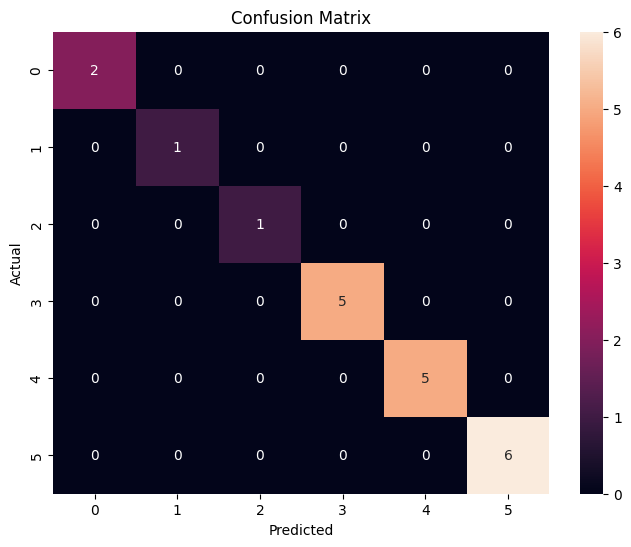

In [31]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

---

# Cross Validation

Evaluate model stability.

In [32]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    model,

    X,

    y,

    cv=5
)

print(scores)

print(
    "Average Accuracy:",
    scores.mean()
)

[1.   1.   0.95 0.95 1.  ]
Average Accuracy: 0.9800000000000001


---

# Save Trained Model

Save the fertilizer recommendation model for deployment.

In [33]:
pickle.dump(

    model,

    open(
        "fertilizer_model.pkl",
        "wb"
    )
)

print(
    "Fertilizer Model Saved"
)

Fertilizer Model Saved


---

# Test Fertilizer Recommendation

In [34]:
sample = X.iloc[[0]]

prediction = model.predict(
    sample
)

fertilizer_name = fertilizer_encoder.inverse_transform(
    prediction
)

print(
    "Recommended Fertilizer:",
    fertilizer_name[0]
)

Recommended Fertilizer: Urea
